In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from itertools import combinations
from sklearn.metrics import mean_squared_error

In [14]:
# Load dataset
df = pd.read_csv("Training Set_11.csv",index_col=0)
df

,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,1.00,2.00,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,...,-0.25111,-0.23408,-0.24280,-0.25121,31.60,61.84,221.94,251.94,1.73952,-0.23268
5-IMes(Me),1.00,1.80,-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,...,-0.24786,-0.23158,-0.24162,-0.24870,30.16,63.78,219.11,247.82,1.73538,-0.22952
5-IPr,1.80,1.00,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,...,-0.25299,-0.23952,-0.25146,-0.25613,29.49,62.57,198.12,226.10,1.73784,-0.23608
"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,...,-0.26154,-0.25844,-0.26562,-0.25147,24.49,66.27,171.17,206.26,1.73388,-0.24368
5-IPr**,6.14,1.00,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,...,-0.26097,-0.25692,-0.25009,-0.25588,22.39,62.91,155.83,192.42,1.74199,-0.24136
5-IPr*,6.50,1.00,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,...,-0.26207,-0.26152,-0.26535,-0.24701,23.72,62.93,160.72,195.84,1.73997,-0.24433
5-SIMes,1.00,1.90,-0.448808,-1805.4289,-1805.9985,0.569576,-1807.4938,2.05731,1.99780,174.72873,...,-0.25051,-0.23458,-0.24228,-0.25078,31.91,58.51,225.06,242.92,1.74547,-0.23307
5-SIPr,2.60,1.00,0.668129,-2041.0793,-2041.8184,0.739147,-2043.3607,2.06240,1.99323,168.67786,...,-0.25536,-0.24060,-0.25102,-0.25734,28.48,60.30,197.82,219.37,1.74288,-0.23792
5-IXyOMe(Me),1.00,2.00,-0.484674,-2033.1753,-2033.7816,0.606229,-2035.3382,2.06151,1.98327,172.68660,...,-0.24790,-0.23160,-0.24083,-0.24860,28.88,64.84,217.95,247.51,1.73310,-0.22917


In [15]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn import metrics

x = df[['BL(C28-Pd)', '%Vbur(3.0Å)']]
y = df[['ΔΔG_Exp']]
x_array = np.array(x)
y_array = np.array(y)
loo = LeaveOneOut()
y_testall = []
y_predall = []
for train_i, test_i in loo.split(x):
    x_train, x_test = x_array[train_i], x_array[test_i]
    y_train, y_test = y_array[train_i], y_array[test_i]
    
    model = LinearRegression()
    model.fit(X = x_train, y = y_train)
    y_pred = model.predict(x_test)
    
    y_testall += list(y_test)
    y_predall += list(y_pred)
    
rr = metrics.r2_score(y_testall, y_predall)
ms_error = metrics.mean_squared_error(y_testall, y_predall)

print("r2 =", rr, ",", "rmse =", ms_error)

r2 = 0.9850061936662962 , rmse = 0.007959041784898964


In [16]:
x1 = df[['BL(C28-Pd)', '%Vbur(3.0Å)']]
y1 = df['ΔΔG_Exp']
regr = linear_model.LinearRegression()
regr.fit(x1,y1)
y_pred1 = regr.predict(x1)
r2 = regr.score(x1,y1)
print("rmse =", mean_squared_error(y1, y_pred1))
print("r2 =", regr.score(x1,y1))
print(regr.coef_)
print(regr.intercept_)

rmse = 0.0037618892701910055
r2 = 0.9929130866892668
[4.83170767 0.11811156]
-14.573002558257306


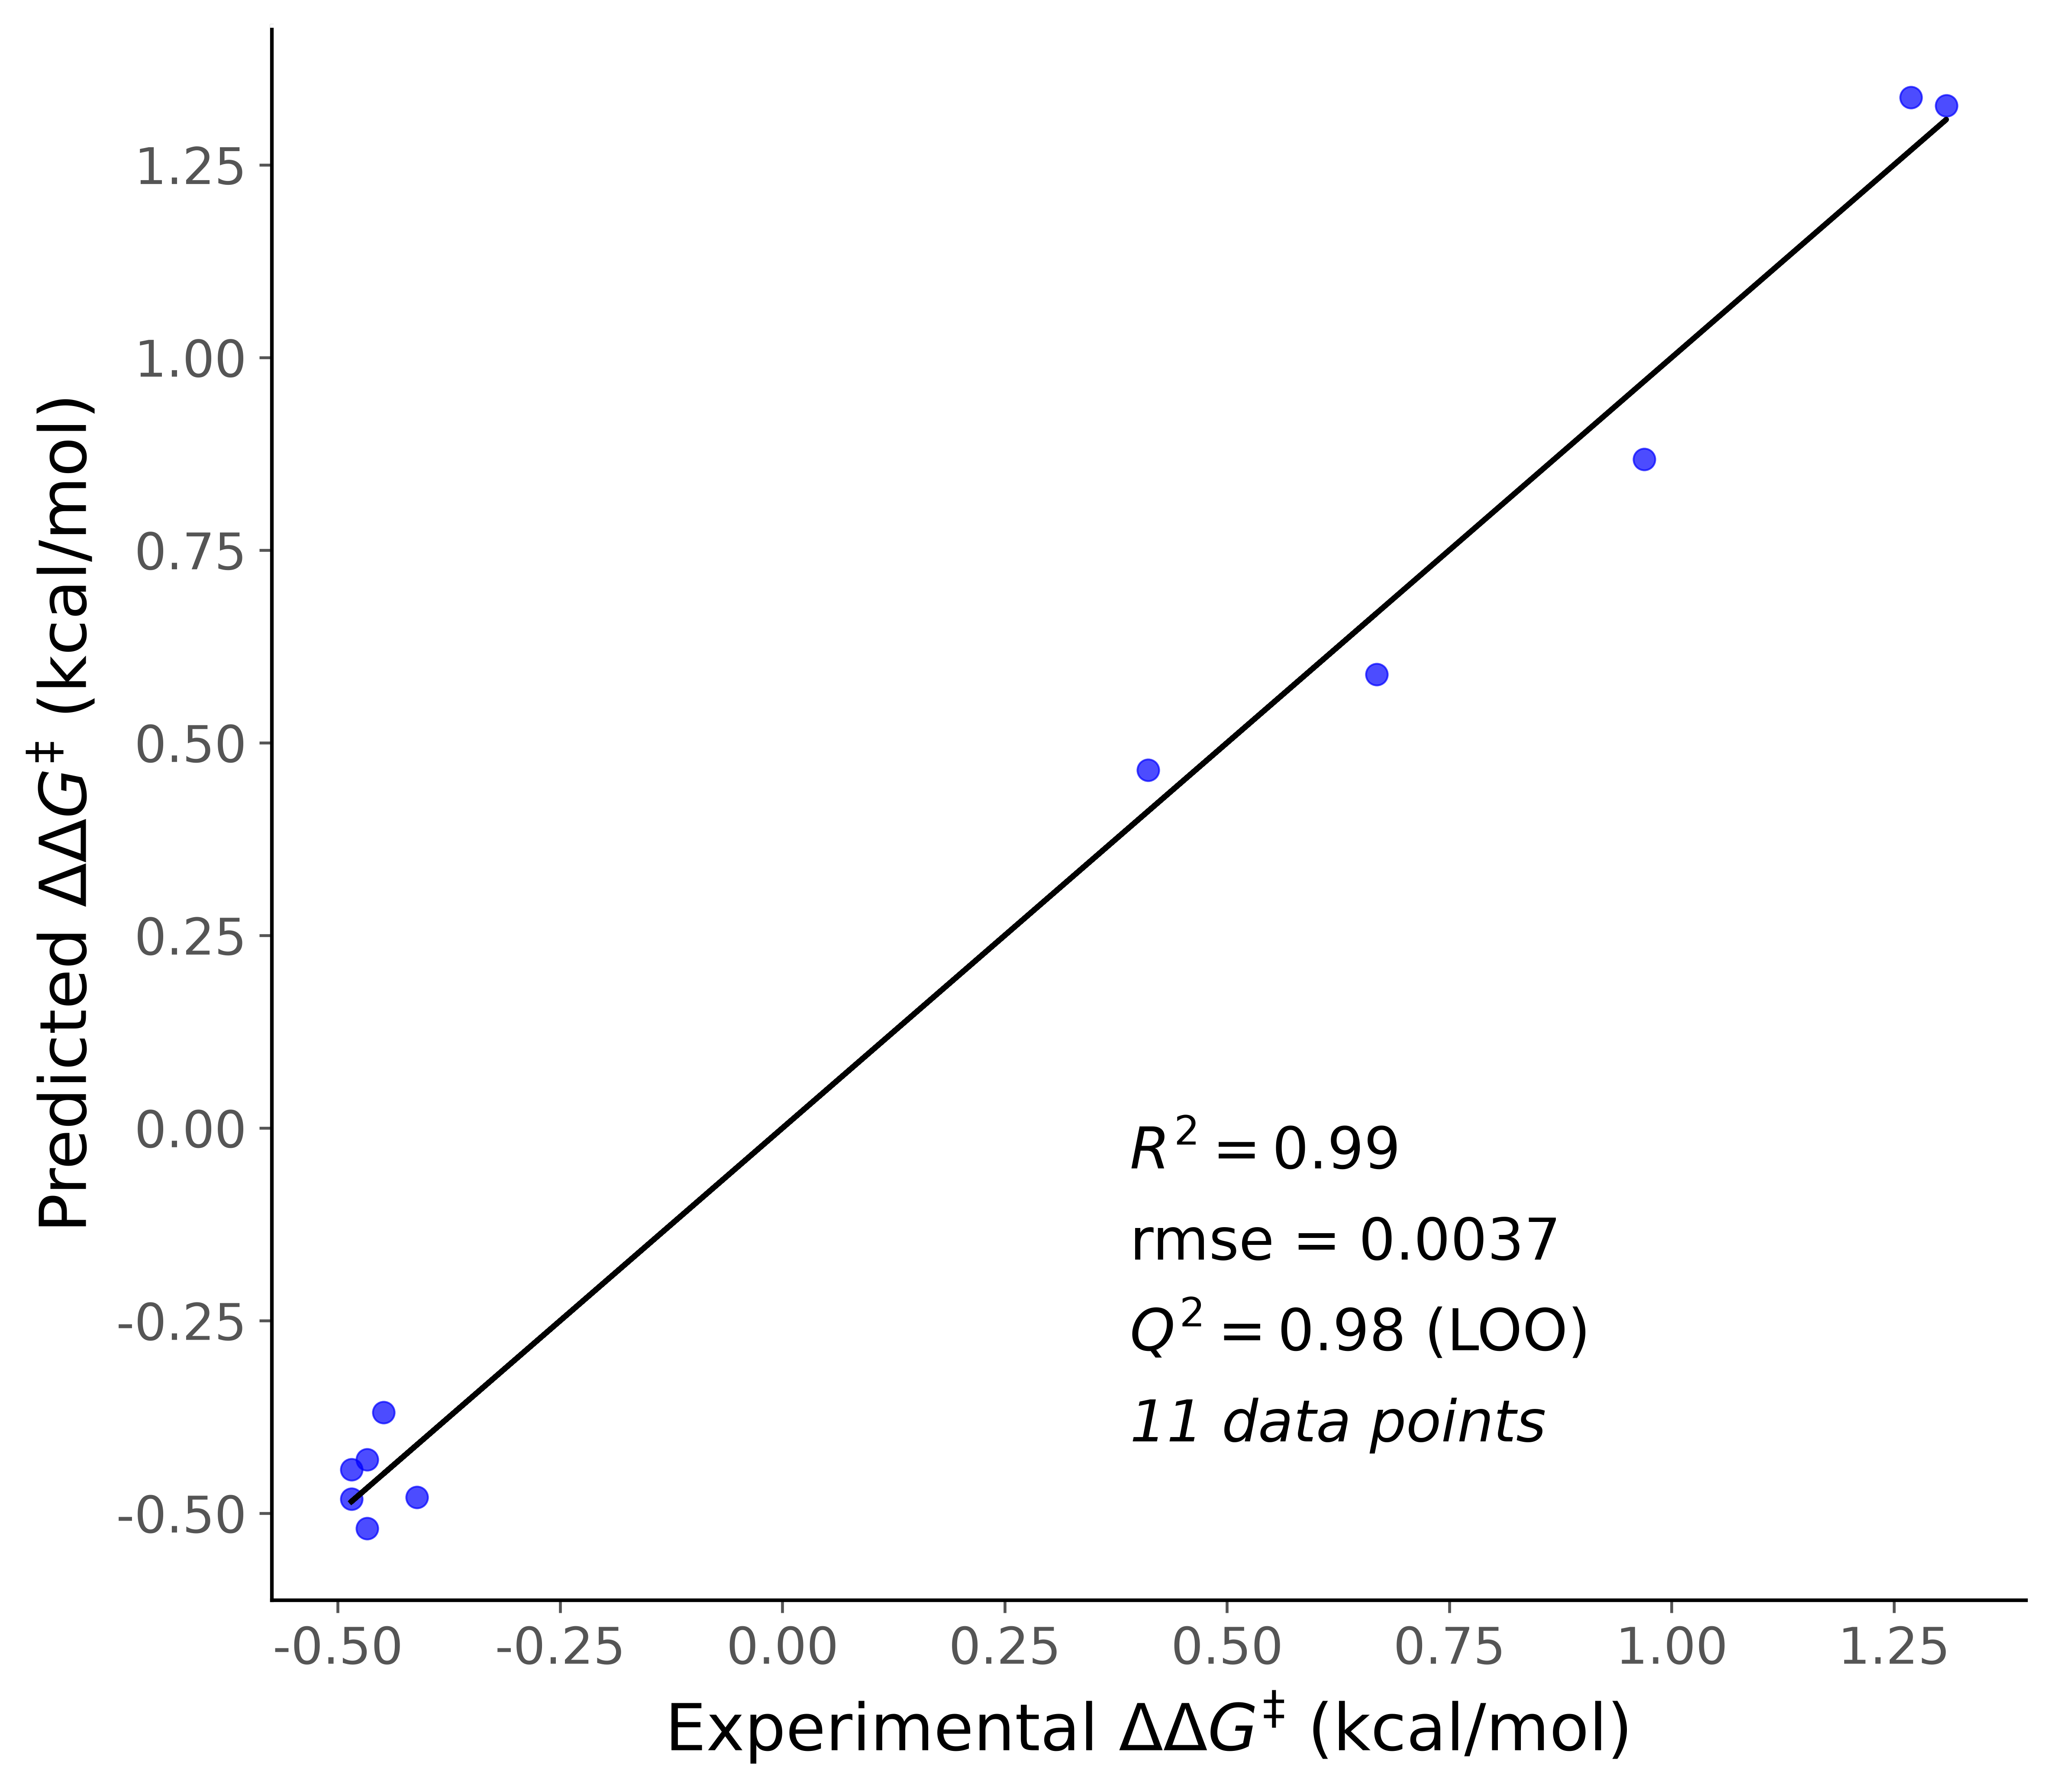

In [17]:
from matplotlib.ticker import FormatStrFormatter

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

fig.text(0.55, 0.35, '$R^2= 0.99$', fontsize = 16)
fig.text(0.55, 0.30, 'rmse = 0.0037', fontsize = 16)
fig.text(0.55, 0.25, '$Q^2= 0.98$ (LOO)', fontsize = 16)
fig.text(0.55, 0.20, '11 data points', fontsize = 16, style = 'italic')
fig.tight_layout()

plt.savefig('LR_fig3.png', bbox_inches='tight')

In [18]:
percent_vbur = 50.2
bond_length = 2.12257

In [19]:
# Model equation parameters
coefficient_vbur = 0.12
coefficient_bl = 4.83
intercept = -14.57

In [20]:
Y_pred_V = coefficient_vbur * percent_vbur + coefficient_bl * bond_length + intercept

In [21]:
print(Y_pred_V)

1.7060130999999998


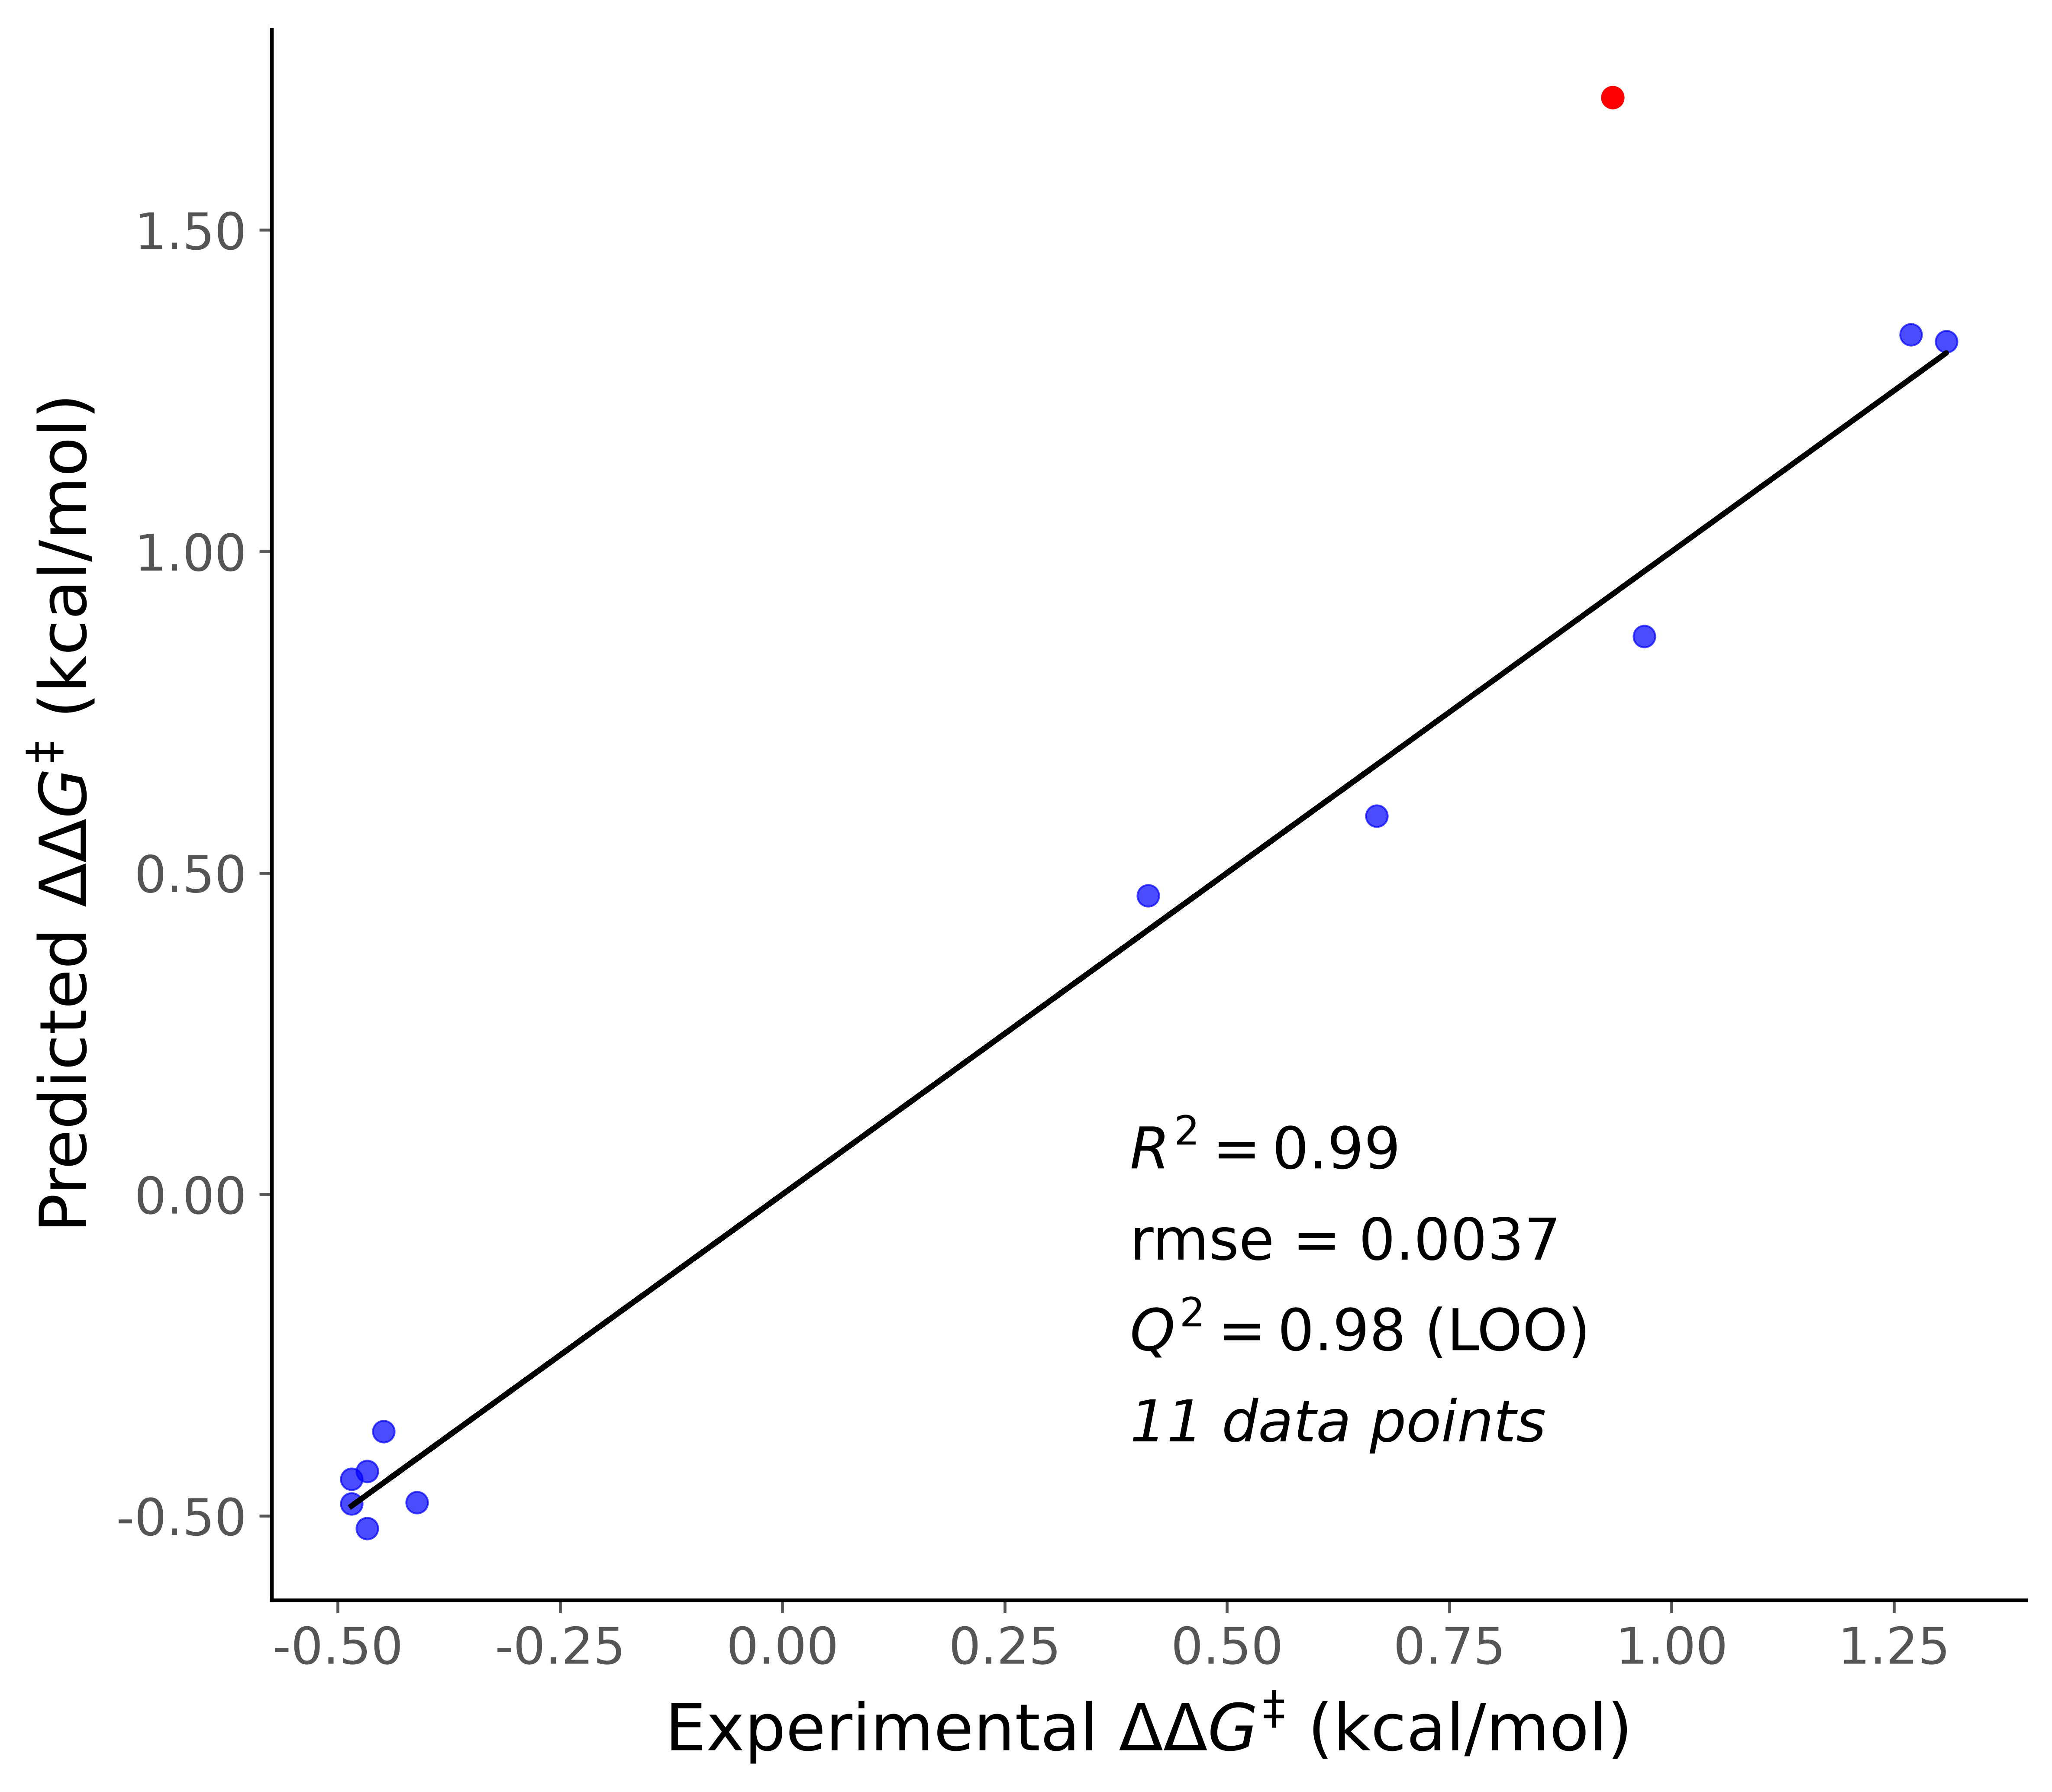

In [22]:
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

# Original plot and scatter
ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)

# New point: Y_actual = 0.933482, Y_Pred_V = 1.7060131 (in red)
ax.scatter(0.933482, 1.7060131, edgecolor='r', facecolor='r', label='New Point')

# Axis labels and formatting
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

# Equation and statistics
fig.text(0.55, 0.35, '$R^2= 0.99$', fontsize = 16)
fig.text(0.55, 0.30, 'rmse = 0.0037', fontsize = 16)
fig.text(0.55, 0.25, '$Q^2= 0.98$ (LOO)', fontsize = 16)
fig.text(0.55, 0.20, '11 data points', fontsize = 16, style = 'italic')
fig.tight_layout()

plt.savefig('Figure S6.png', bbox_inches='tight')